In [1]:
import requests
from PIL import Image
from io import BytesIO
from diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_upscale import StableDiffusionUpscalePipeline
import torch

# load model and scheduler
model_id = "stabilityai/stable-diffusion-x4-upscaler"
pipeline = StableDiffusionUpscalePipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipeline = pipeline.to("cuda")

/net/st1/export/clusterhome/robertwiebe/testvenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 372/372 [00:00<00:00, 1737.80it/s]]
CLIPTextModel LOAD REPORT from: /usr/people/robertwiebe/.cache/huggingface/hub/models--stabilityai--stable-diffusion-x4-upscaler/snapshots/572c99286543a273bfd17fac263db5a77be12c4c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  3.62it/s]


In [2]:
low_res_img = Image.open("hat_guy.png").convert("RGB")
# low_res_img = low_res_img.resize((128, 128))

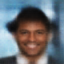

In [4]:
low_res_img

In [7]:
prompt = "portrait photo of a man wearing a hat, realistic skin texture, natural lighting, high detail, sharp focus, DSLR photograph"

upscaled_image = pipeline(
    prompt=prompt,
    image=low_res_img,
    num_inference_steps=75,
    guidance_scale=1,
    noise_level=20,
    negative_prompt="blurry, dots, lines, pattern, low quality, worst quality, artifacts, noise, grain, jpeg artifacts, deformed, distorted face, extra fingers, bad anatomy, unrealistic skin, plastic skin, overexposed, underexposed, cartoon, painting, illustration, CGI, anime, stylized, artistic"
).images[0]

  0%|          | 0/75 [00:00<?, ?it/s]

100%|██████████| 75/75 [00:03<00:00, 21.26it/s]


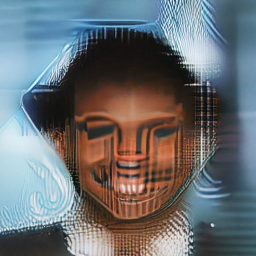

In [8]:
upscaled_image

In [1]:
from diffusers.pipelines.qwenimage.pipeline_qwenimage_edit import QwenImageEditPipeline
import torch
from PIL import Image

# Load the pipeline
pipeline = QwenImageEditPipeline.from_pretrained("Qwen/Qwen-Image-Edit-2509")
pipeline.to(torch.bfloat16)
pipeline.to("cuda")

# Load trained LoRA weights for in-scene editing
pipeline.load_lora_weights("valiantcat/Qwen-Image-Edit-2509-Upscale2K", weight_name="qwen_image_edit_2509_upscale.safetensors")

# Load input image
image = Image.open("hat_guy.png").convert("RGB")

# Define in-scene editing prompt
prompt = "Upscale this picture to 4K resolution."

# Generate edited image with enhanced scene understanding
inputs = {
    "image": image,
    "prompt": prompt,
    "generator": torch.manual_seed(12345),
    "true_cfg_scale": 4.0,
    "negative_prompt": " ",
    "num_inference_steps": 50,
}

with torch.inference_mode():
    output = pipeline(**inputs)
    output_image = output.images[0]
    output_image.save("edited_image.png")

/net/st1/export/clusterhome/robertwiebe/testvenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 6/6 [00:09<00:00,  1.51s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 72.00 MiB. GPU 0 has a total capacity of 19.68 GiB of which 67.31 MiB is free. Including non-PyTorch memory, this process has 19.61 GiB memory in use. Of the allocated memory 19.26 GiB is allocated by PyTorch, and 197.51 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [1]:
from diffusers.pipelines.qwenimage.pipeline_qwenimage_edit import QwenImageEditPipeline
import torch
from PIL import Image

# Load the pipeline
pipeline = QwenImageEditPipeline.from_pretrained("Qwen/Qwen-Image-Edit-2511")
pipeline.to(torch.bfloat16)
pipeline.to("cuda")

# Load trained LoRA weights for in-scene editing
pipeline.load_lora_weights("valiantcat/Qwen-Image-Edit-2511-Upscale2K", weight_name="qwen_image_edit_2511_upscale.safetensors")

# Load input image
image = Image.open("hat_guy.png").convert("RGB")

# Define in-scene editing prompt
prompt = "Upscale this picture to 4K resolution."

# Generate edited image with enhanced scene understanding
inputs = {
    "image": image,
    "prompt": prompt,
    "generator": torch.manual_seed(12345),
    "true_cfg_scale": 4.0,
    "negative_prompt": " ",
    "num_inference_steps": 50,
}

with torch.inference_mode():
    output = pipeline(**inputs)
    output_image = output.images[0]
    output_image.save("edited_image.png")


Loading pipeline components...: 100%|██████████| 6/6 [00:54<00:00,  9.13s/it]


OutOfMemoryError: CUDA out of memory. Tried to allocate 72.00 MiB. GPU 0 has a total capacity of 19.68 GiB of which 67.31 MiB is free. Including non-PyTorch memory, this process has 19.61 GiB memory in use. Of the allocated memory 19.26 GiB is allocated by PyTorch, and 197.51 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import torch
from diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_latent_upscale import StableDiffusionLatentUpscalePipeline
from diffusers.pipelines.stable_diffusion.pipeline_onnx_stable_diffusion_upscale import OnnxStableDiffusionUpscalePipeline

In [1]:
from diffusers.pipelines.stable_diffusion_xl.pipeline_stable_diffusion_xl_img2img import StableDiffusionXLImg2ImgPipeline
import torch
from PIL import Image

In [2]:
pipe = StableDiffusionXLImg2ImgPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16
).to("cuda")

Loading pipeline components...: 100%|██████████| 7/7 [00:22<00:00,  3.17s/it]


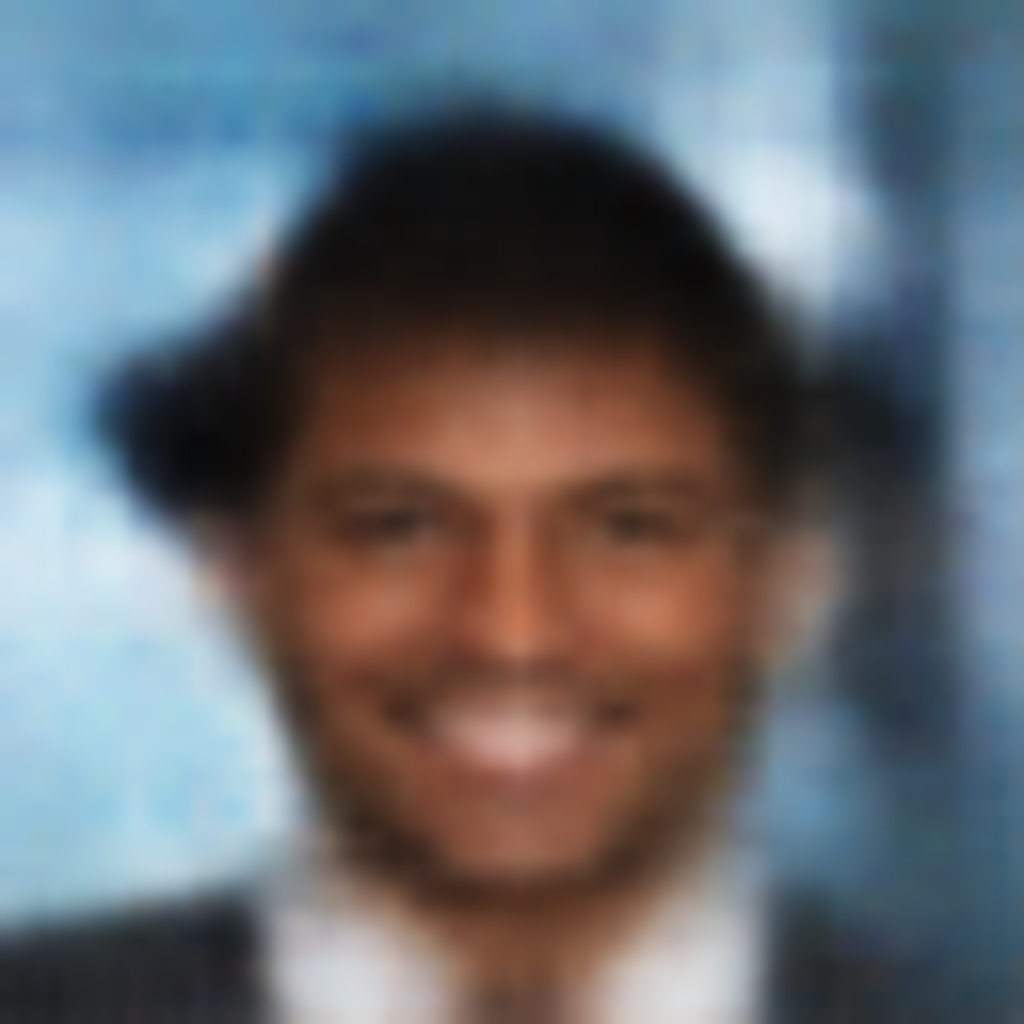

In [28]:
image = Image.open("hat_guy.png").convert("RGB")
image = image.resize((1024, 1024), Image.BICUBIC)
image

In [29]:
prompt = "ultra realistic portrait photo, natural skin texture, sharp focus, DSLR"

intermediate = pipe(
    prompt=prompt,
    image=image,
    strength=0.35,
    guidance_scale=5.0,
    num_inference_steps=200,
    negative_prompt="blurry, dots, lines, pattern, low quality, worst quality, artifacts, noise, grain, jpeg artifacts, deformed, distorted face, extra fingers, bad anatomy, unrealistic skin, plastic skin, overexposed, underexposed, cartoon, painting, illustration, CGI, anime, stylized, artistic"
).images[0]
result = pipe(
    prompt=prompt,
    image=intermediate,
    strength=0.3,
    guidance_scale=5.0,
    num_inference_steps=200,
    negative_prompt="blurry, dots, lines, pattern, low quality, worst quality, artifacts, noise, grain, jpeg artifacts, deformed, distorted face, extra fingers, bad anatomy, unrealistic skin, plastic skin, overexposed, underexposed, cartoon, painting, illustration, CGI, anime, stylized, artistic"
).images[0]

result.save("upscaled.png")

100%|██████████| 70/70 [00:27<00:00,  2.55it/s]
/net/st1/export/clusterhome/robertwiebe/testvenv/lib/python3.11/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
100%|██████████| 60/60 [00:24<00:00,  2.47it/s]


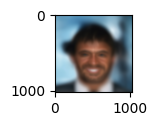

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize=(1, 1))
plt.imshow(result)